In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
# Load the CSV file into a pandas DataFrame, specifying encoding, separator, 
# and skipping the initial log line
df = pd.read_csv('/content/putty.csv', encoding='latin1', sep=';', skiprows=1)

# Display the first few rows and column information to understand the data structure
print("Original DataFrame head:")
display(df.head())
print("\nDataFrame Info:")
df.info()

Original DataFrame head:


,Tempo,DHT22,LM35,Termopar_K,DS18B20,Setpoint,Erro,Acao controle
0,0.0,24.10°C,0.00°C,25.50°C,24.9°C,50°C,0.0,0
1,0.6,24.10°C,24.10°C,25.25°C,24.9°C,50°C,25.9,255
2,1.5,24.10°C,24.10°C,25.50°C,24.9°C,50°C,25.9,255
3,2.1,24.10°C,24.10°C,25.75°C,24.9°C,50°C,25.9,255
4,2.7,24.10°C,24.10°C,25.50°C,24.9°C,50°C,25.9,255



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913 entries, 0 to 912
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Tempo          913 non-null    float64
 1   DHT22          913 non-null    object 
 2   LM35           913 non-null    object 
 3   Termopar_K     913 non-null    object 
 4   DS18B20        913 non-null    object 
 5   Setpoint       913 non-null    object 
 6   Erro           913 non-null    float64
 7   Acao controle  913 non-null    int64  
dtypes: float64(2), int64(1), object(5)
memory usage: 57.2+ KB


In [21]:
# Identify the temperature columns (next 4 columns after 'Tempo')
tempo_col_index = df.columns.get_loc('Tempo')
temp_cols = df.columns[tempo_col_index + 1 : tempo_col_index + 5]

# Strip '°C' from temperature columns and convert to numeric
for col in temp_cols:
    if df[col].dtype == 'object': # Only process if the column is of object type (string)
        df[col] = df[col].str.replace('°C', '', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce') # Convert to numeric, coercing errors to NaN
    # df[col] = df[col].fillna(0) # Fill NaN values with 0

# Display the cleaned DataFrame head and info to verify changes
print("\nCleaned DataFrame head:")
display(df.head())
print("\nCleaned DataFrame Info:")
df.info()


Cleaned DataFrame head:


,Tempo,DHT22,LM35,Termopar_K,DS18B20,Setpoint,Erro,Acao controle
0,0.0,24.1,0.0,25.50,24.9,50°C,0.0,0
1,0.6,24.1,24.1,25.25,24.9,50°C,25.9,255
2,1.5,24.1,24.1,25.50,24.9,50°C,25.9,255
3,2.1,24.1,24.1,25.75,24.9,50°C,25.9,255
4,2.7,24.1,24.1,25.50,24.9,50°C,25.9,255



Cleaned DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913 entries, 0 to 912
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Tempo          913 non-null    float64
 1   DHT22          913 non-null    float64
 2   LM35           913 non-null    float64
 3   Termopar_K     913 non-null    float64
 4   DS18B20        913 non-null    float64
 5   Setpoint       913 non-null    object 
 6   Erro           913 non-null    float64
 7   Acao controle  913 non-null    int64  
dtypes: float64(6), int64(1), object(1)
memory usage: 57.2+ KB


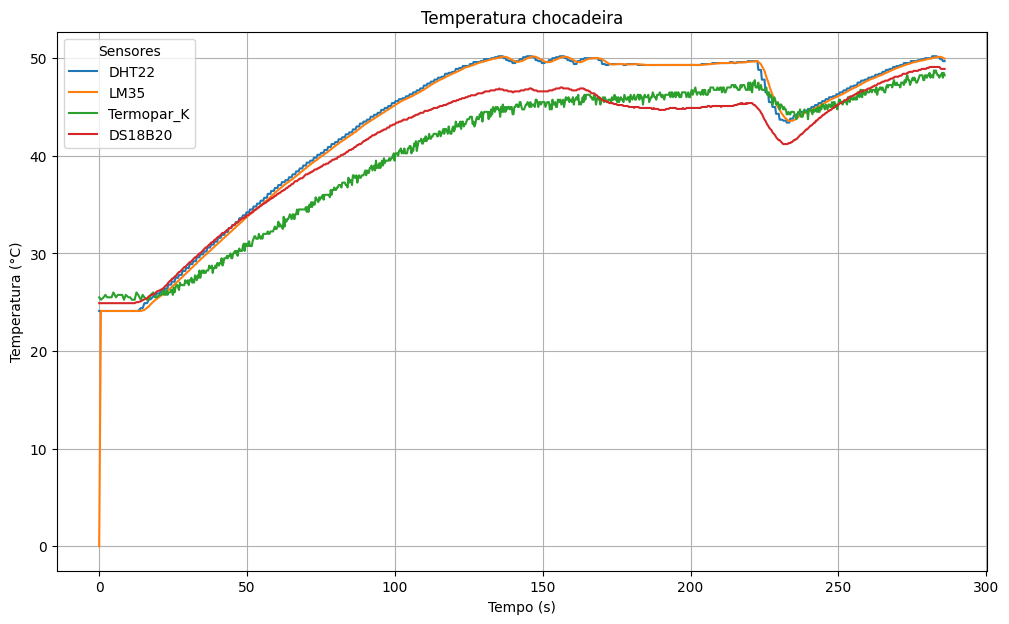

In [22]:
# Plot the data
plt.figure(figsize=(12, 7))

# Set 'Tempo' as the x-axis
x_axis = 'Tempo'

# Plot each temperature column against 'Tempo'
for col in temp_cols:
    sns.lineplot(x=df[x_axis], y=df[col], label=col)

plt.title('Temperatura chocadeira')
plt.xlabel('Tempo (s)')
plt.ylabel('Temperatura (°C)')
plt.legend(title='Sensores')
plt.grid(True)
plt.show()